# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Daniel Kolev  |        6160255       |
| Zain Qureshi  |        6143555       |
| Deyan Papazov  |        6191150       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [1]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Loading the data

In [2]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

We will now start with implementing our perceptron. We will create a Perceptron class which will store the functionality

In [3]:
# Put your code for Question 1 here
class Perceptron:
    ##
    # Constructor for the precptron class.
    # Returns a preceptron with an array of weights, a bias term and a learning rate.
    ##
    def __init__(self, sizet = 10, rate = 0.01):
        self.weights = np.random.rand(sizet)
        self.bias = np.random.rand()
        self.alpha = rate
    

    ##
    # Predicts the label for a set of samples given the input features, weights and bias.
    ##
    def predict(self, input_features):
        return np.where(np.dot(self.weights, input_features.T) + self.bias >= 0, 1, 0)
    
    ##
    # Loss function that returns the differnece between the label and predicred label.
    ##
    def loss(self, prediction, label):
        return label - prediction
    
    ##
    # Updates the weights and bias term of the preceptron over a number of epochs.
    # For each sample we get the prediction, calculate loss and update weights + bias.
    ##
    def train(self, train_data, train_labels, epochs = 100):
        errors_per_epoch = []

        for i in range(epochs):
            error = 0

            for (row, actual) in zip(train_data,train_labels):
                prediction = self.predict(row)
                loss = self.loss(prediction, actual)
                self.weights = [w + row[j] * self.alpha * loss for j,w in enumerate(self.weights)]
                self.bias = self.bias + self.alpha * loss

            for (pred, label) in zip(self.predict(train_data), train_labels):
                if pred != label: error += 1

        
            errors_per_epoch.append(error)
        return errors_per_epoch

In [4]:
##
# Calculates accuracy for the predicted labels against the ground truths
##
def accuracy(predictions, labels):
    return np.mean(np.where(predictions == labels, 1, 0)) * 100

---
### Logic Gates:

OR prediction: [0 1 1 1]
OR accuracy: 100.0
AND prediction: [0 0 0 1]
AND accuracy: 100.0
XOR prediction: [1 1 0 0]
XOR accuracy: 50.0


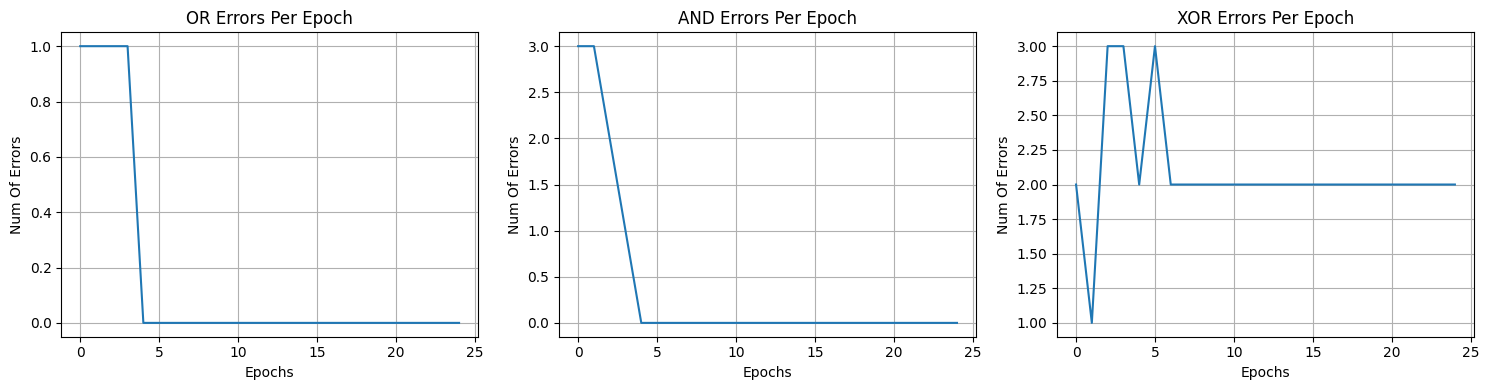

In [6]:
##
# Here we have the general truth table as input
# and then we have the respective output labels
# for each logic gate.
# We then plot all 3 gates against the no. of errors per epoch
##
input_x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
input_y = [
    np.array([0, 1, 1, 1]),
    np.array([0, 0, 0, 1]),
    np.array([0, 1, 1, 0])
]
gate_name = [
    "OR",
    "AND",
    "XOR"
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, (gate, name) in enumerate(zip(input_y, gate_name)):
    perceptron = Perceptron(sizet = 2, rate = 0.1)
    errors_per_epochs = perceptron.train(input_x, gate, epochs = 25)
    predictions = perceptron.predict(input_x)

    print(f"{name} prediction: {predictions}")
    print(f"{name} accuracy: {accuracy(perceptron.predict(input_x), gate)}")

    ax = axes[i]
    ax.plot(errors_per_epochs)
    ax.grid()
    ax.set_title(f"{name} Errors Per Epoch" )
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Num Of Errors")
plt.tight_layout()
plt.show()


- From this we can see that that we eventually converge on the number of errors we have per epoch.
- After a few epochs we have 0 errors and the weights have stabilized by this point and are not updated anymore.
- However this is only true for the OR and AND gate as the class labels are lineraly seperable.
- On the other hand, for the XOR gate, we keep on updating the weights but we are never able to get a better fit than 50% accuracy as the two class labels are not linearly seperable.

#### Question 2

10 neurons would be required for this task as we need 1 neuron for each feature of the input data. For the given data, we have 10 features per sample, thus this is the reason for having 10 neurons.

#### Question 3

We will need 7 output neurons. This is because the number of output neurons is equal to the number of output classes to which we classify the input. In our case we want to classify the input into 1 out of 7 classes, so we need 7 output neurons.


#### Question 4

For the initial design, the network will use one hidden layer with 10 neurons. This is a solid starting point because a single hidden layer can handle most basic classification tasks without making the math too complicated. I chose 10 neurons to match the number of input features, which gives the model enough neurons to find patterns without overcomplicating things.

#### Question 5

Based on the fact that we will hvae one singel class label as an output per sample, I would use a the softmax function as the activation function for the output layer. The reason for this is that it gives mutually exclusive labels where it outputs probability scores for each class, and we would select the class with the highest probability.

For the hidden layers, I would use a ReLU. The vanishing gradient problem occurs when gradients become exponentially small during backpropagation due to repeated multiplication of derivatives less than 1. This prevents early layers from learning effectively, making deep networks difficult to train. Activation functions like sigmoid and tanh cause this because their derivatives are bounded below 1. ReLU mitigates this problem since its derivative is 1 for positive inputs, preventing gradient shrinkage.

#### Question 6

This is the diagram for question 6. We have drawn the arros only for 1 input neuron and only for 1 hidden neuron. This is to enchance readibility. In the real neuron netwokr each input perceptron will be connected to each hidden perceptron with weith w1 to w10. Each hidden perceptron will be connected to each output perceptron with value bias1 to bias7


<img src="../042cc58e-1.png" alt="Neural Network Schematic" width="500"/>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [10]:
class Linear:
    def __init__(self, in_features, out_features, init_type = 'normal'):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_typee: initialization type of weights and biases
        """

        # Different types of initialsizations for the weights in the linear layer
        if init_type == 'normal':
            self.weight = np.random.randn(in_features, out_features) * 0.01
        elif init_type == 'uniform':
            self.weight = np.random.uniform(-0.5, 0.5, (in_features, out_features))
        elif init_type == 'zeros':
            self.weight = np.zeros((in_features, out_features))

        self.bias = np.zeros(out_features)

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        return np.dot(x, self.weight) + self.bias
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = np.dot(self.cache.T, dupstream)

        self.bias_grad = np.sum(dupstream, axis=0)

        return np.dot(dupstream, self.weight.T)

        

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [5]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        pass
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [6]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        pass
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        pass
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        pass

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [7]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """

    pass

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [8]:
def train(net, inputs, labels, criterion, lr):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    
    pass

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>

### Tests

In [1]:
import unittest

In [ ]:
##
# Tests for the Perceptron class
##
class TestPerceptron(unittest.TestCase):
    # Checks if the dimensions of the weights and bias are 
    # correctly initialized based on the input dimensions
    def test_init_dimensions(self):
            p = Perceptron(3)
            self.assertEqual(p.dimensions, 3)
            self.assertEqual(len(p.w), 3)

    # Checks if the output of the predict function is either 0 or 1 
    # for binary classification
    def test_predict_output_values(self):
        np.random.seed(42)
        p = Perceptron(2)
        X = np.array([[0, 0], [1, 1]])
        preds = p.predict(X)
        for v in preds:
            self.assertIn(v, [0, 1])

    # Checks if the output of the predict function has the correct 
    # shape based on the input data
    def test_predict_output_shape(self):
        np.random.seed(42)
        p = Perceptron(2)
        X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        preds = p.predict(X)
        self.assertEqual(preds.shape, (4,))

    # Cheks that the perceptron can learn the AND function 
    # which is a linearly separable function
    def test_train_and(self):
        np.random.seed(42)
        p = Perceptron(2)
        X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        Y = np.array([0, 0, 0, 1])
        p.train(X, Y, epochs=1000, learning_rate=0.1)
        preds = p.predict(X)
        self.assertTrue(np.array_equal(preds, Y))

    # This shows that the perceptron cannot learn the XOR function
    # which is not linearly separable
    def test_train_xor(self):
        np.random.seed(42)
        p = Perceptron(2)
        X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        Y = np.array([0, 1, 1, 0])
        p.train(X, Y, epochs=1000, learning_rate=0.1)
        preds = p.predict(X)
        self.assertFalse(np.array_equal(preds, Y))

    # Tests the accuracy function
    def test_acc(self):
        y_true = np.array([0, 1, 1, 0])
        y_pred = np.array([0, 0, 1, 1])
        self.assertEqual(accuracy(y_true, y_pred), 0.5)

unittest.main(argv=[''], exit=False)


In [ ]:
##
# Tests for the Linear class
##

class TestLinear(unittest.TestCase):
    # Checks if the dimensions of the weights and bias are correctly
    #  initialized based on the input and output features
    def test_forward_shape(self):
            layer = Linear(3, 5, init_strategy="he")
            x = np.random.randn(10, 3)
            out = layer.forward(x)
            self.assertEqual(out.shape, (10, 5))

    # Checks if the output of the forward function is all 
    # zeros when the weights and bias are initialized to zeros
    def test_forward_zeros_init(self):
        layer = Linear(3, 2)
        x = np.ones((4, 3))
        out = layer.forward(x)
        np.testing.assert_array_equal(out, np.zeros((4, 2)))

    # Checks the shape of the output of the backward function, 
    # which should be the same as the input to the forward function
    def test_backward_shape(self):
        layer = Linear(3, 5, init_strategy="he")
        x = np.random.randn(10, 3)
        layer.forward(x)
        dupstream = np.random.randn(10, 5)
        dx = layer.backward(dupstream)
        self.assertEqual(dx.shape, (10, 3))

    # Checks the shape of the gradients with respect to the weights
    # and bias, which should be the same as the dimensions of the 
    # weights and bias
    def test_backward_gradients_shape(self):
        layer = Linear(3, 5, init_strategy="he")
        x = np.random.randn(10, 3)
        layer.forward(x)
        dupstream = np.random.randn(10, 5)
        layer.backward(dupstream)
        self.assertEqual(layer.weight_grad.shape, (3, 5))
        self.assertEqual(layer.bias_grad.shape, (5,))

unittest.main(argv=[''], exit=False)

In [ ]:
##
# Tests for Activation functions
##
class TestActivationFunctions(unittest.TestCase):
    # Checks if the output of the ReLU activation function is correct
    def test_relu_forward(self):
        relu = ReLU()
        x = np.array([[-1, 0, 1], [2, -3, 4]])
        out = relu.apply(x)
        expected = np.array([[0, 0, 1], [2, 0, 4]])
        self.assertTrue(np.array_equal(out, expected))

    # Checks if the derivative of the ReLU activation function is correct
    def test_relu_derivative(self):
        relu = ReLU()
        x = np.array([[-1, 0, 1], [2, -3, 4]])
        out = relu.apply_derivative(x)
        expected = np.array([[0, 0, 1], [1, 0, 1]])
        self.assertTrue(np.array_equal(out, expected))

    # Checks if the output of the Identity activation function is correct
    def test_identity_forward(self):
        identity = Identity()
        x = np.array([[1, 2], [3, 4]])
        out = identity.apply(x)
        self.assertTrue(np.array_equal(out, x))

    # Checks if the derivative of the Identity activation function is correct
    def test_identity_derivative(self):
        identity = Identity()
        x = np.array([[1, 2], [3, 4]])
        out = identity.apply_derivative(x)
        expected = np.ones_like(x)
        self.assertTrue(np.array_equal(out, expected))

    # Checks if the value function of the SoftmaxCrossEntropy 
    # class computes the loss correctly for a simple case
    def test_softmax_cross_entropy(self):
        sce = SoftmaxCrossEntropy()
        labels = np.array([0, 1])
        logits = np.array([[2.0, 1.0], [1.0, 2.0]])
        loss = sce.value(labels, logits)
        probs = sce.softmax(logits)
        expected_loss = -np.mean(np.log(probs[np.arange(2), labels]))
        self.assertTrue(np.isclose(loss, expected_loss))

    # Checks if the grad function of the SoftmaxCrossEntropy class
    # computes the gradient correctly for a simple case
    def test_softmax_cross_entropy_grad(self):
        sce = SoftmaxCrossEntropy()
        labels = np.array([0, 1])
        logits = np.array([[2.0, 1.0], [1.0, 2.0]])
        grad = sce.grad(labels, logits)
        probs = sce.softmax(logits)
        probs[np.arange(2), labels] -= 1
        expected_grad = probs / labels.shape[0]
        self.assertTrue(np.allclose(grad, expected_grad))

    # Checks if the forward function of Activation
    #  applies the activation function correctly
    def test_activation_forward(self):
        relu = ReLU()
        activation = Activation(relu)
        x = np.array([[-1, 0, 1], [2, -3, 4]])
        out = activation.forward(x)
        expected = relu.apply(x)
        self.assertTrue(np.array_equal(out, expected))

    # Checks if the backward function of Activation
    #  computes the gradient correctly
    def test_activation_backward(self):
        relu = ReLU()
        activation = Activation(relu)
        x = np.array([[-1, 0, 1], [2, -3, 4]])
        activation.forward(x)
        dupstream = np.array([[1, 1, 1], [1, 1, 1]])
        grad = activation.backward(dupstream)
        expected_grad = dupstream * relu.apply_derivative(x)
        self.assertTrue(np.array_equal(grad, expected_grad))

unittest.main(argv=[''], exit=False)